# Portfolio Risk Analysis

# Risk & Diversification Analysis Dashboard

## Python & Financial Data | 2015 - 2024

---
**Author:** Angelos Kesidis
**Target Firms:** JPMorgan Chase ∙ Goldman Sachs ∙ BlackRock
**Period:** 2015-01-01 → 24-01-01
**Data:** June 2026
**Tools:** Python ∙ NumPy ∙ Pandas ∙ Matplotlib ∙ yfinance

---

## Portfolio Risk & Diversification Analysis

This project evaluates the risk profile and diversification benefits of a custom-weighted portfolio consisting of five diversified stocks (2015–2024). Before coding, you must import the necessary libraries (e.g., yfinance, pandas, numpy, matplotlib) and globally define your asset tickers, timeframe parameters, and weight distributions. The script will then fetch the historical adjusted closing prices to calculate the annualized volatility of each individual stock, generate covariance and correlation matrices to analyze their co-movement, and finally apply the portfolio weights to measure and decompose the total portfolio risk into its systematic and diversifiable components.

## The Role of a Junior Quant Analyst at BlackRock
In this scenario, we are adopting the perspective of a junior quantitative analyst who is handed a portfolio and must answer three fundamental questions:

1. How risky is each stock individually? (Assessing volatility per stock)

2. How do the assets move together? (Analyzing the correlation matrix and heatmap)

3. How much risk can be eliminated through diversification? (Decomposing systematic vs. diversifiable risk)

## Workflow:
1. Data Collection & Diagnostics
2. Normalization & Visual Comparison
3. Log Returns
4. Annualized Returns & Volatility per Stock
5. Covariance & Correlation Matrix
6. Portfolio Variance & Volatility
7. Systematic vs Diversifiable Risk

In [30]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
 
warnings.filterwarnings("ignore")   # suppress yfinance/pandas version warnings
 
# ── GLOBAL PARAMETERS ────────────────────────────────────────────────────────
STOCKS       = ["AAPL", "MSFT", "JPM", "JNJ", "XOM"]
START        = "2015-01-01"
END          = "2024-01-01"
TRADING_DAYS = 250          # industry-standard annualisation factor

# Conviction-weighted portfolio
# AAPL 35% · MSFT 25% · JPM 20% · JNJ 10% · XOM 10%
WEIGHTS = np.array([0.35, 0.25, 0.20, 0.10, 0.10])

# ── WEIGHT VALIDATION ────────────────────────────────────────────────────────
assert np.isclose(WEIGHTS.sum(), 1.0), "Portfolio weights do not sum to 1.0!"

# Section 1 — Data Collection & Portfolio Setup
We download adjusted closing prices for five large-cap U.S. equities across four distinct sectors, plus the S&P 500 and NASDAQ as our market benchmarks.

| Ticker | Company | Sector |
|--------|---------|--------|
| AAPL | Apple Inc. | Technology |
| MSFT | Microsoft Corp. | Technology |
| JPM | JPMorgan Chase | Financials |
| JNJ | Johnson & Johnson | Healthcare |
| XOM | Exxon Mobil | Energy |

**Period:** 2015-01-01 → 2024-01-01

Portfolio 2: Custom weights [0.35, 0.25, 0.20, 0.10, 0.10]

Adjusted closing prices account for dividends and stock splits — the correct input for return calculations.

In [31]:
# ============================================================
# SECTION 1 — Data Collection & Diagnostics
# ============================================================
print("=" * 65)
print(" SECTION 1 — Data Collection & Diagnostics")
print("=" * 65)
 
raw_data = yf.download(STOCKS, start=START, end=END, auto_adjust=True)["Close"]
data     = raw_data.ffill().dropna()   # forward-fill holiday gaps, drop residual NaNs
 
print(f"  Shape      : {data.shape[0]} rows × {data.shape[1]} columns")
print(f"  Date range : {data.index[0].date()}  →  {data.index[-1].date()}")
print(f"  Columns    : {list(data.columns)}")
print()
print("  Missing values per column:")
print(data.isnull().sum().to_string())
print()
print("  First 5 rows:")
print(data.head().to_string())
print()
print("  Last 5 rows:")
print(data.tail().to_string())
print()
print("  No missing values." if data.isnull().sum().sum() == 0
      else "  Warning: NaNs remain!")

[                       0%                       ]

 SECTION 1 — Data Collection & Diagnostics


[*********************100%***********************]  5 of 5 completed

  Shape      : 2264 rows × 5 columns
  Date range : 2015-01-02  →  2023-12-29
  Columns    : ['AAPL', 'JNJ', 'JPM', 'MSFT', 'XOM']

  Missing values per column:
Ticker
AAPL    0
JNJ     0
JPM     0
MSFT    0
XOM     0

  First 5 rows:
Ticker           AAPL        JNJ        JPM       MSFT        XOM
Date                                                             
2015-01-02  24.192610  76.110886  46.274326  39.681736  57.145554
2015-01-05  23.511061  75.579330  44.837715  39.316826  55.581932
2015-01-06  23.513271  75.207947  43.675129  38.739769  55.286469
2015-01-07  23.842979  76.868240  43.741779  39.231972  55.846649
2015-01-08  24.759085  77.472649  44.719246  40.386101  56.776196

  Last 5 rows:
Ticker            AAPL         JNJ         JPM        MSFT        XOM
Date                                                                 
2023-12-22  191.433090  144.608795  158.576035  367.440796  93.793533
2023-12-26  190.889236  145.241333  159.513840  367.519257  94.005203
2023-12

# Section 2 — Normalization & Visual Comparison
Raw price levels are not directly comparable across stocks. We normalize all series to base 100 on the first trading day, so the y-axis reads as "cumulative % gain from Jan 2015."$$P_{\text{norm},t} = \frac{P_t}{P_0} \times 100$$

Chart are produced:

Chart A: The five stocks only — to identify relative winners within the portfolio.

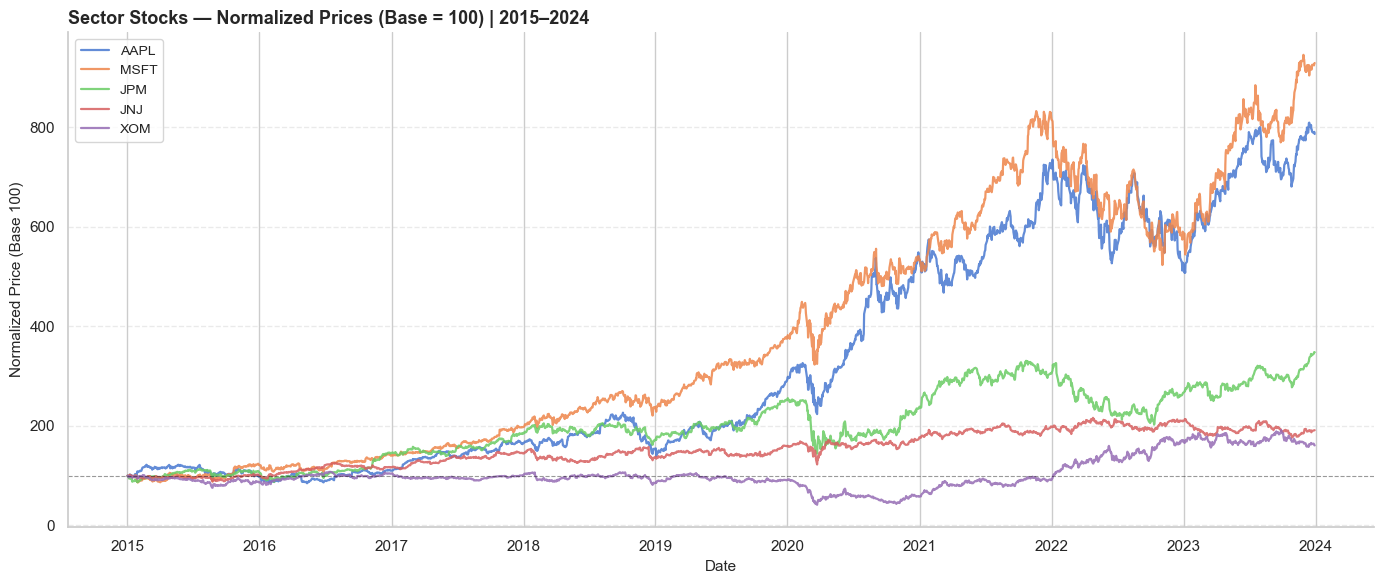

In [32]:
# ============================================================
# SECTION 2 — Normalization & Visual Comparison
# ============================================================

# ── Chart A: Sector stocks only ───────────────────────────────────────────────
# Normalize to Base 100: P_norm,t = (P_t / P_0) * 100
normalized = (data / data.iloc[0]) * 100
 
fig, ax = plt.subplots(figsize=(14, 6))
for col in STOCKS:
    ax.plot(normalized[col], label=col, linewidth=1.6, alpha=0.85)
 
ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("Sector Stocks — Normalized Prices (Base = 100) | 2015–2024",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Normalized Price (Base 100)", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

---
## Section 3 — Log Returns
We compute log returns for our time-series analysis, as they offer distinct mathematical advantages when evaluating performance over multiple periods.

| Method | Formula | Best used when |
|--------|---------|----------------|
| Log Return | $\ln(P_t / P_{t-1})$ | Single asset, multiple periods |

**Why log returns here?**

-**Time-additive:** multi-period log return = sum of single-period log returns

-**Approximate normality:** better statistical properties for regression & risk models

-**Symmetric:** equal magnitude for +x% and -x% moves


 SECTION 3 — Log Returns (first 5 rows)
Ticker          AAPL       JNJ       JPM      MSFT       XOM
Date                                                        
2015-01-05 -0.028576 -0.007008 -0.031538 -0.009238 -0.027743
2015-01-06  0.000094 -0.004926 -0.026271 -0.014786 -0.005330
2015-01-07  0.013925  0.021836  0.001525  0.012625  0.010081
2015-01-08  0.037703  0.007832  0.022100  0.028994  0.016508
2015-01-09  0.001072 -0.013723 -0.017540 -0.008441 -0.001411


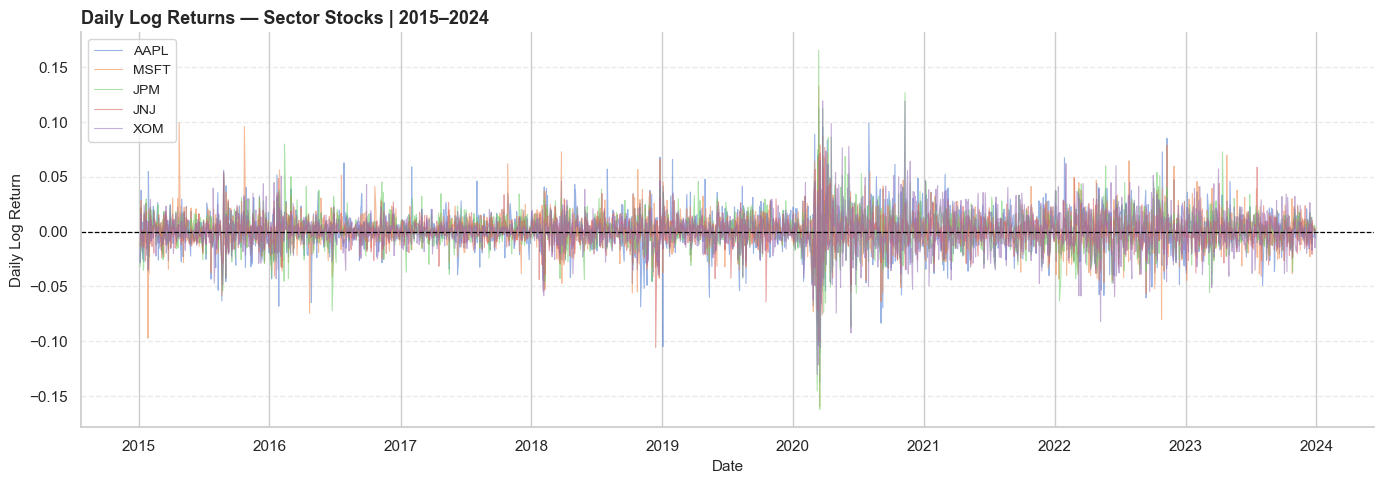

In [33]:
# ============================================================
# SECTION 3 — Log Returns
# ============================================================

# Formula: r_t = ln(P_t / P_{t-1})
log_returns = np.log(data / data.shift(1)).dropna()
 
print("\n" + "=" * 65)
print(" SECTION 3 — Log Returns (first 5 rows)")
print("=" * 65)
print(log_returns.head().to_string())

# ── Plot: Daily log returns — stocks only ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for col in STOCKS:
    ax.plot(log_returns[col], label=col, alpha=0.55, linewidth=0.8)
 
ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
ax.set_title("Daily Log Returns — Sector Stocks | 2015–2024",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Daily Log Return", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Section 4 - Annualized Returns per Stock
Daily mean log returns are scaled to an annual figure using the standard convention of 250 trading days per year (U.S. equity markets are open $\approx$ 252 days, but 250 is the established industry convention).$$R_{\text{annual}} = \bar{r}_{\text{daily}} \times 250$$

Results are ranked from highest to lowest to quickly identify the top performer.


  SECTOR STOCKS — ANNUALIZED LOG RETURNS
  Ticker   | Annual Return (%)
  ----------------------------
  MSFT     |            24.63%
  AAPL     |            22.79%
  JPM      |            13.78%
  JNJ      |             7.18%
  XOM      |             5.26%
  ----------------------------
  Top performer  : MSFT  (24.63%)
  Worst performer: XOM  (5.26%)


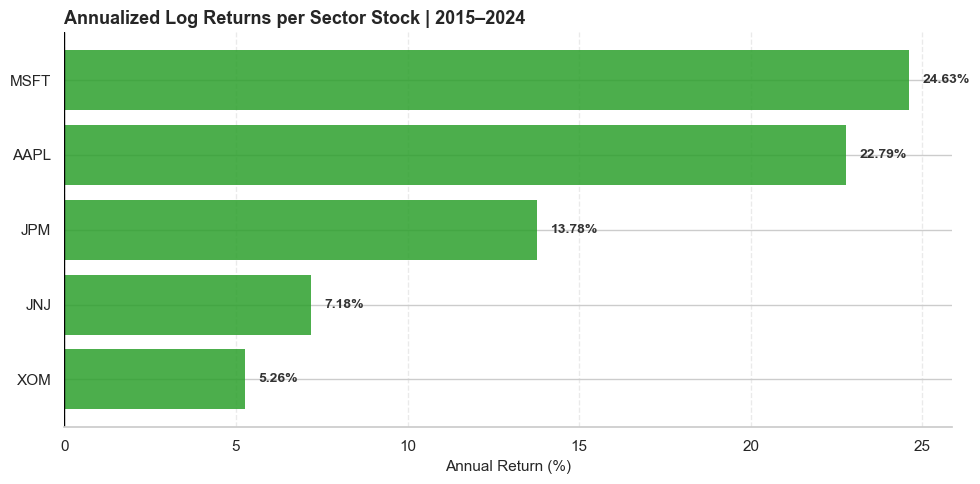


--- Risk Analysis — Ranked Low to High ---
       Annual Std Dev (%) Annual Variance (%)
Ticker                                       
JNJ                18.31%               3.35%
JPM                27.62%               7.63%
MSFT                27.7%               7.67%
XOM                28.48%               8.11%
AAPL               28.93%               8.37%


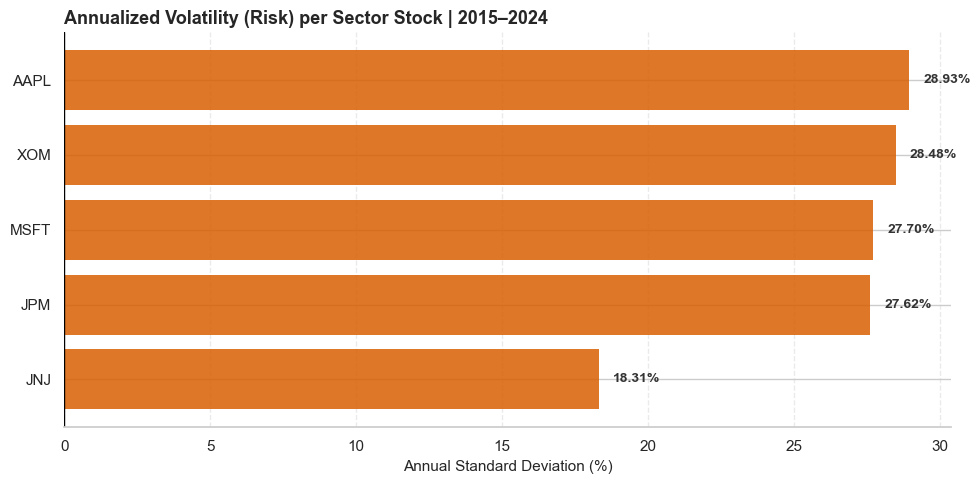

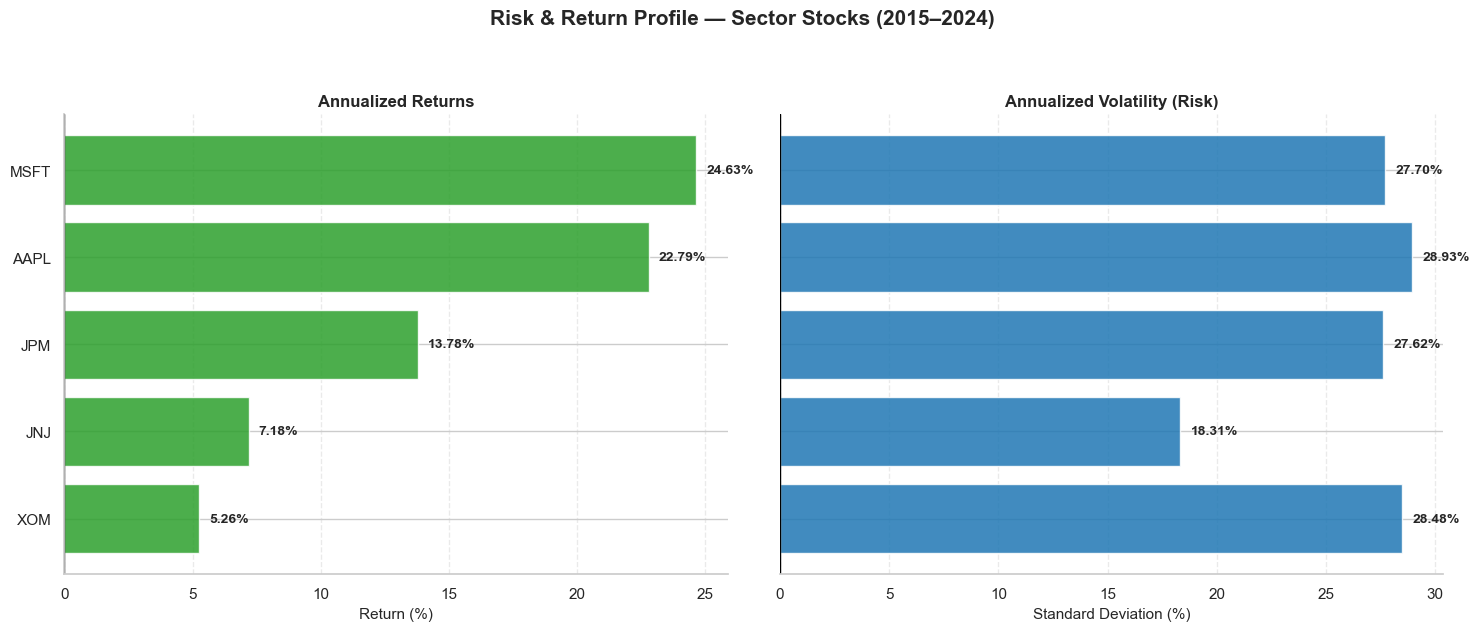

In [34]:
# =======================================================================
# SECTION 4 — Annualized Returns per Stock & Annual Volatility per Stock
# =======================================================================

annual_log_returns = log_returns[STOCKS].mean() * TRADING_DAYS
 
summary = (
    pd.DataFrame({"Annual Return (%)": (annual_log_returns * 100).round(2)})
    .sort_values("Annual Return (%)", ascending=False)
)
 
best  = summary.index[0]
worst = summary.index[-1]
 
print("\n" + "=" * 50)
print("  SECTOR STOCKS — ANNUALIZED LOG RETURNS")
print("=" * 50)
print(f"  {'Ticker':<8} | {'Annual Return (%)':>17}")
print("  " + "-" * 28)
for ticker, row in summary.iterrows():
    print(f"  {ticker:<8} | {row['Annual Return (%)']:>16.2f}%")
print("  " + "-" * 28)
print(f"  Top performer  : {best}  ({summary.loc[best,  'Annual Return (%)']:.2f}%)")
print(f"  Worst performer: {worst}  ({summary.loc[worst, 'Annual Return (%)']:.2f}%)")
print("=" * 50)

# ── Horizontal bar chart for Returns ─────────────────────────────────────────────────
summary_asc = summary.sort_values("Annual Return (%)", ascending=True)
bar_colors  = ["#d62728" if v < 0 else "#2ca02c"
               for v in summary_asc["Annual Return (%)"]]
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(summary_asc.index, summary_asc["Annual Return (%)"],
               color=bar_colors, alpha=0.85, edgecolor="none")
 
for bar in bars:
    w  = bar.get_width()
    x  = w + 0.4 if w >= 0 else w - 0.4
    ha = "left" if w >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f"{w:.2f}%", va="center", ha=ha,
            fontsize=10, fontweight="bold", color="#333333")
 
ax.axvline(0, color="black", linewidth=1.0)
ax.set_title("Annualized Log Returns per Sector Stock | 2015–2024",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Annual Return (%)", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

# Annual Std Dev and Variance - Stocks
annual_std_dev = log_returns[STOCKS].std() * (250 ** 0.5)
annual_variance = log_returns[STOCKS].var() * 250

# Risk ranking table — lowest to highest risk
risk_table = pd.DataFrame({
    "Annual Std Dev (%)":  (annual_std_dev  * 100).round(2),
    "Annual Variance (%)": (annual_variance * 100).round(2)
}).sort_values(by="Annual Std Dev (%)", ascending=True)
 
risk_table_display = risk_table.applymap(lambda x: f"{x}%")
print("\n--- Risk Analysis — Ranked Low to High ---")
print(risk_table_display.to_string())


# ── Horizontal bar chart for Volatility ─────────────────────────────────────────────
risk_asc = risk_table.sort_values("Annual Std Dev (%)", ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
bars_vol = ax.barh(risk_asc.index, risk_asc["Annual Std Dev (%)"],
                   color="#d95f02", alpha=0.85, edgecolor="none")

for bar in bars_vol:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{w:.2f}%", va="center", ha="left",
            fontsize=10, fontweight="bold", color="#333333")

ax.axvline(0, color="black", linewidth=1.0)
ax.set_title("Annualized Volatility (Risk) per Sector Stock | 2015–2024",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Annual Standard Deviation (%)", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

# ── Combined Dashboard: Returns vs Volatility (Side-by-Side) ────────────────────────
combo_df = pd.DataFrame({
    "Return": summary["Annual Return (%)"],
    "Risk": risk_table["Annual Std Dev (%)"]
}).sort_values("Return", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
colors_ret = ["#d62728" if v < 0 else "#2ca02c" for v in combo_df["Return"]]
bars1 = ax1.barh(combo_df.index, combo_df["Return"], color=colors_ret, alpha=0.85)
for bar in bars1:
    w = bar.get_width()
    x = w + 0.4 if w >= 0 else w - 0.4
    ha = "left" if w >= 0 else "right"
    ax1.text(x, bar.get_y() + bar.get_height() / 2, f"{w:.2f}%", 
             va="center", ha=ha, fontsize=10, fontweight="bold")

ax1.set_title("Annualized Returns", fontsize=12, fontweight="bold")
ax1.set_xlabel("Return (%)", fontsize=11)
ax1.axvline(0, color="black", linewidth=1.0)
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

bars2 = ax2.barh(combo_df.index, combo_df["Risk"], color="#1f77b4", alpha=0.85)
for bar in bars2:
    w = bar.get_width()
    ax2.text(w + 0.5, bar.get_y() + bar.get_height() / 2, f"{w:.2f}%", 
             va="center", ha="left", fontsize=10, fontweight="bold")

ax2.set_title("Annualized Volatility (Risk)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Standard Deviation (%)", fontsize=11)
ax2.axvline(0, color="black", linewidth=1.0)
ax2.grid(axis="x", linestyle="--", alpha=0.4)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

fig.suptitle("Risk & Return Profile — Sector Stocks (2015–2024)", fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

# Section 5 - Covariance & Correlation Matrix
To analyze how the assets move together, we calculate both the covariance and correlation matrices of the daily log returns. The daily covariance matrix is scaled to an annual figure by multiplying by 250, reflecting the joint variability over a full trading year. In contrast, the correlation matrix normalizes these relationships into a bounded scale of [−1,1] and requires no time-scaling.


$$\text{Cov}_{\text{annual}} = \text{Cov}_{\text{daily}} \times 250$$

The resulting relationships are visually represented as a heatmap using base Matplotlib (plt.imshow()) rather than Seaborn. This ensures a lightweight, dependency-efficient workflow for quickly identifying highly correlated asset pairs and diversification opportunities.


 SECTION 5 — COVARIANCE & CORRELATION MATRIX

  Annual Covariance Matrix:
Ticker      AAPL       JNJ       JPM      MSFT       XOM
Ticker                                                  
AAPL    0.083719  0.019766  0.035861  0.055962  0.026981
JNJ     0.019766  0.033512  0.020956  0.020997  0.017374
JPM     0.035861  0.020956  0.076284  0.035514  0.045256
MSFT    0.055962  0.020997  0.035514  0.076719  0.024316
XOM     0.026981  0.017374  0.045256  0.024316  0.081088

  Correlation Matrix:
Ticker   AAPL    JNJ    JPM   MSFT    XOM
Ticker                                   
AAPL    1.000  0.373  0.449  0.698  0.327
JNJ     0.373  1.000  0.414  0.414  0.333
JPM     0.449  0.414  1.000  0.464  0.575
MSFT    0.698  0.414  0.464  1.000  0.308
XOM     0.327  0.333  0.575  0.308  1.000

  Diagonal check (must all be 1.0): [1. 1. 1. 1. 1.]
  Average pairwise correlation    : 0.4357
  Low avg correlation → real diversification benefit available.


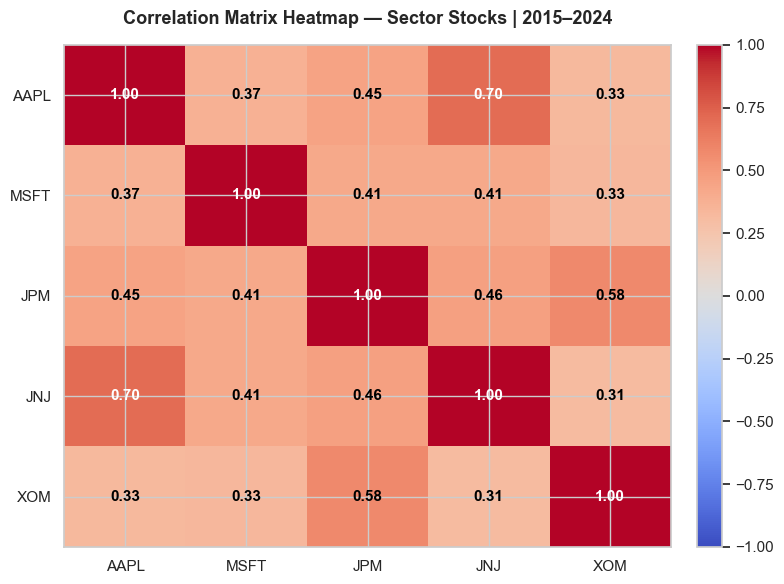

In [35]:
# ====================================================
# Covariance & Correlation Matrix
# ===================================================

# Covariance matrix — annualized (× 250)
cov_matrix  = log_returns.cov() * TRADING_DAYS   # annualized
corr_matrix = log_returns.corr()                  # never scaled
 
print("\n" + "=" * 65)
print(" SECTION 5 — COVARIANCE & CORRELATION MATRIX")
print("=" * 65)
print("\n  Annual Covariance Matrix:")
print(cov_matrix.round(6).to_string())
print("\n  Correlation Matrix:")
print(corr_matrix.round(3).to_string())
print(f"\n  Diagonal check (must all be 1.0): "
      f"{np.diag(corr_matrix.values).round(6)}")
 
# Average pairwise correlation (exclude self-correlation on diagonal)
mask = np.ones(corr_matrix.shape, dtype=bool)
np.fill_diagonal(mask, False)
avg_corr = corr_matrix.values[mask].mean()
print(f"  Average pairwise correlation    : {avg_corr:.4f}")
print("  Low avg correlation → real diversification benefit available.")
 
# ── Correlation heatmap — pure Matplotlib (no Seaborn) ───────
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1,
               aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
 
for i in range(len(STOCKS)):
    for j in range(len(STOCKS)):
        val   = corr_matrix.values[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=11, fontweight="bold", color=color)
 
ax.set_xticks(range(len(STOCKS)))
ax.set_yticks(range(len(STOCKS)))
ax.set_xticklabels(STOCKS, fontsize=11)
ax.set_yticklabels(STOCKS, fontsize=11)
ax.set_title("Correlation Matrix Heatmap — Sector Stocks | 2015–2024",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Section 6 - Portfolio Variance & Volatility
To determine the overall risk of our custom-weighted portfolio, we must calculate its total variance and subsequent volatility. Portfolio variance cannot be determined by simply averaging the individual stock volatilities; it must account for how the assets interact with one another, which is captured by the annual covariance matrix ($\Sigma$).Using linear algebra, the portfolio variance is calculated as the dot product of the transposed weights vector ($\mathbf{w}^T$), the annual covariance matrix ($\Sigma$), and the weights vector ($\mathbf{w}$):$$\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}$$

The portfolio volatility, which represents the annualized standard deviation (the actual risk metric we can interpret as a percentage), is simply the square root of the portfolio variance:$$\sigma_p = \sqrt{\sigma_p^2}$$

In Python, this matrix multiplication is efficiently executed using NumPy's np.dot() function alongside array transposition (weights.T). This approach provides a highly optimized and scalable mathematical computation for risk assessment, avoiding computationally expensive loops.


Number of Stocks   : 5
Weight per Stock   : 0.35
Sum of weights   : 1.0

===== Custom-Weight Portfolio Variance & Volatility =====
Portfolio Variance   : 0.038996
Portfolio Volatility : 19.75%

===== Risk Decomposition =====
Systematic Risk (SR)         : 1.9248%
Diversifiable Risk (DR)      : 1.9748%
Verification SR + DR         : 3.8996%  (= Portfolio Variance ✓)

Worst-Case Variance (ρ=1)    : 0.074276
Actual Portfolio Variance    : 0.038996
Diversification Benefit      : 0.035280
Diversification Ratio        : 47.5%  (% of risk removed)


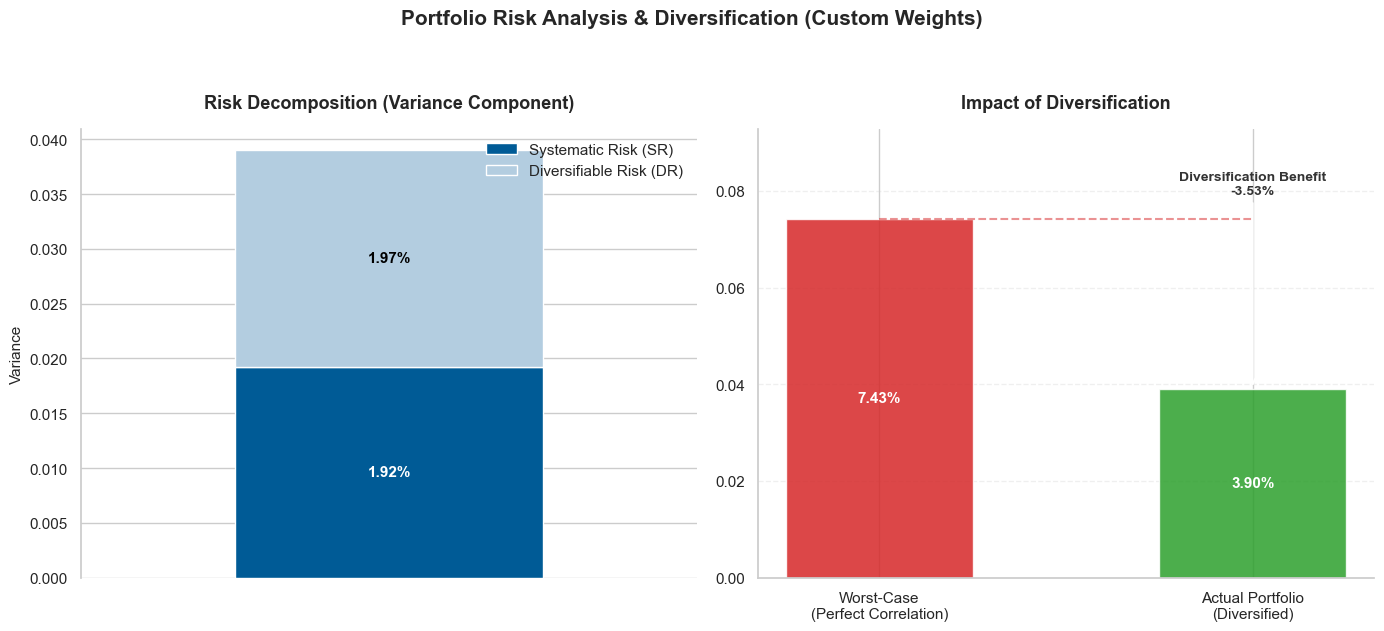

In [36]:
# ============================================================
# SECTION 6 — PORTFOLIO RISK (Custom WEIGHT)
# ============================================================

# Custom -weight portfolio
n = len(STOCKS)

print(f"\nNumber of Stocks   : {n}")
print(f"Weight per Stock   : {round(WEIGHTS_B[0], 6)}")
print(f"Sum of weights   : {round(sum(WEIGHTS_B), 10)}")   # must equal 1.0

# Portfolio Variance and Volatility — matrix form: w^T · Σ · w
portfolio_variance   = np.dot(WEIGHTS_B.T, np.dot(cov_matrix, WEIGHTS_B))
portfolio_volatility = portfolio_variance ** 0.5
print("\n===== Custom-Weight Portfolio Variance & Volatility =====")
print(f"Portfolio Variance   : {portfolio_variance:.6f}")
print(f"Portfolio Volatility : {round(portfolio_volatility * 100, 2)}%")

# ── Systematic vs Diversifiable Risk ─────────────────────────
sr = np.sum(WEIGHTS_B ** 2 * annual_variance[STOCKS].values)
dr = portfolio_variance - sr

# Worst-case: all sectors perfectly correlated (ρ = 1)
worst_case_variance     = (np.sum(WEIGHTS_B * np.sqrt(annual_variance[STOCKS].values))) ** 2
diversification_benefit = worst_case_variance - portfolio_variance
diversification_ratio   = (diversification_benefit / worst_case_variance) * 100

print("\n===== Risk Decomposition =====")
print(f"Systematic Risk (SR)         : {round(sr * 100, 4)}%")
print(f"Diversifiable Risk (DR)      : {round(dr * 100, 4)}%")
print(f"Verification SR + DR         : {round((sr + dr) * 100, 4)}%  (= Portfolio Variance ✓)")
print(f"\nWorst-Case Variance (ρ=1)    : {worst_case_variance:.6f}")
print(f"Actual Portfolio Variance    : {portfolio_variance:.6f}")
print(f"Diversification Benefit      : {diversification_benefit:.6f}")
print(f"Diversification Ratio        : {round(diversification_ratio, 1)}%  (% of risk removed)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
bar_width = 0.5
x_pos = [1]
p1 = ax1.bar(x_pos, sr, width=bar_width, color="#005b96", edgecolor="white", label="Systematic Risk (SR)")
p2 = ax1.bar(x_pos, dr, width=bar_width, bottom=sr, color="#b3cde0", edgecolor="white", label="Diversifiable Risk (DR)")

ax1.text(1, sr / 2, f"{sr*100:.2f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=11)
ax1.text(1, sr + (dr / 2), f"{dr*100:.2f}%", ha='center', va='center', color='black', fontweight='bold', fontsize=11)

ax1.set_xlim(0.5, 1.5)
ax1.set_xticks([])
ax1.set_title("Risk Decomposition (Variance Component)", fontsize=13, fontweight="bold", pad=15)
ax1.set_ylabel("Variance", fontsize=11)
ax1.legend(loc="upper right", frameon=False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["bottom"].set_visible(False)

categories = ["Worst-Case\n(Perfect Correlation)", "Actual Portfolio\n(Diversified)"]
values = [worst_case_variance, portfolio_variance]
colors = ["#d62728", "#2ca02c"]

bars = ax2.bar(categories, values, color=colors, width=0.5, alpha=0.85)
ax2.set_ylim(0, worst_case_variance * 1.25)
ax2.plot([0, 1], [worst_case_variance, worst_case_variance], color="#d62728", linestyle="--", linewidth=1.5, alpha=0.5)
ax2.annotate(
    f"Diversification Benefit\n-{diversification_benefit*100:.2f}%",
    xy=(1, portfolio_variance),
    xytext=(1, worst_case_variance + (worst_case_variance * 0.06)), 
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333'
)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height / 2, 
             f"{height*100:.2f}%", 
             ha='center', va='center', color='white', fontweight='bold', fontsize=11)

ax2.set_title("Impact of Diversification", fontsize=13, fontweight="bold", pad=15)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
fig.suptitle("Portfolio Risk Analysis & Diversification (Custom Weights)", fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


 SECTION 7 — SYSTEMATIC vs DIVERSIFIABLE RISK
  Portfolio Variance (actual)   : 0.03899637
  Systematic Risk   (SR)        : 0.01924790  (1.9248%)
  Diversifiable Risk (DR)       : 0.01974847  (1.9748%)
  Verification SR + DR          : 0.03899637  ✓

  Worst-Case Variance (ρ = 1)   : 0.07427630
  Actual Portfolio Variance     : 0.03899637
  Diversification Benefit       : 0.03527993
  Diversification Ratio         : 47.5%  (risk removed vs ρ=1 baseline)

  Of total portfolio variance:
    49.4% is systematic    (unavoidable — market-wide risk)
    50.6% is diversifiable (already removed by mixing sectors)


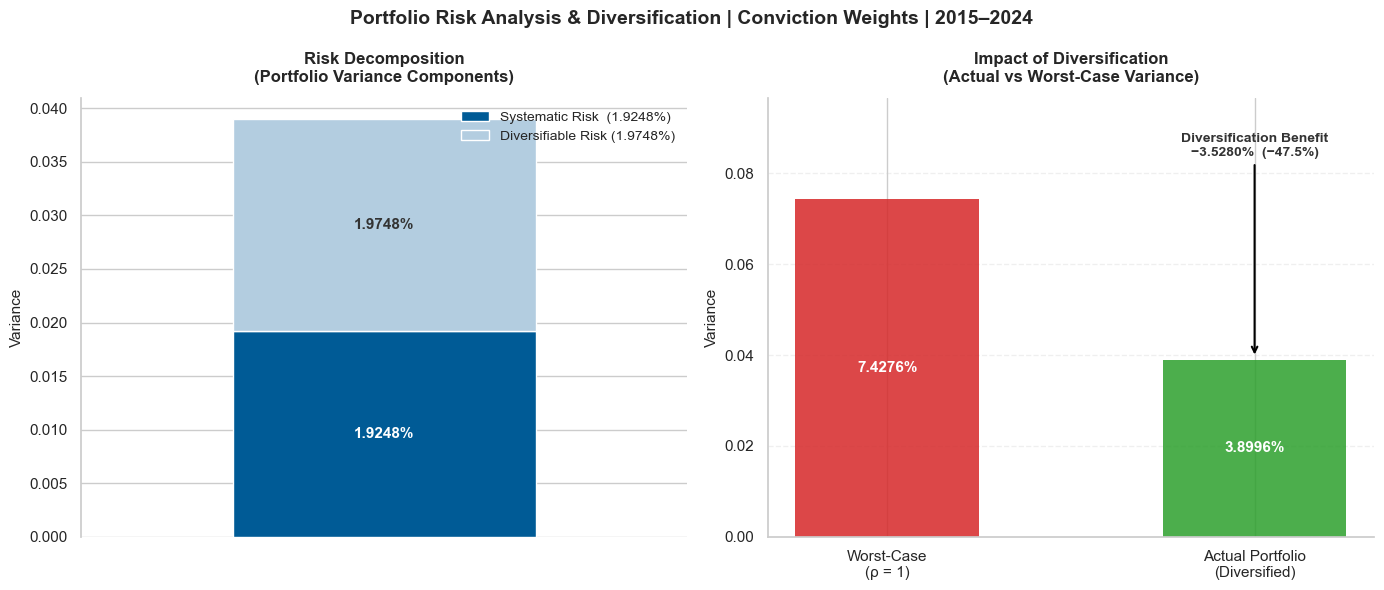

In [37]:
# =============================================================================
# SECTION 7 — Impact of Diversification
# =============================================================================
# Individual annualized variances — stored as plain floats (single brackets)
ind_variances = np.array([
    float(log_returns[s].var() * TRADING_DAYS) for s in STOCKS
])
 
# Systematic and diversifiable components
sr = float(np.sum(WEIGHTS ** 2 * ind_variances))
dr = float(portfolio_variance - sr)
 
# Worst-case benchmark (ρ = 1 for all pairs)
worst_case  = float((np.sum(WEIGHTS * np.sqrt(ind_variances))) ** 2)
div_benefit = worst_case - portfolio_variance
div_ratio   = (div_benefit / worst_case) * 100
 
# Verification: sr + dr must exactly equal portfolio_variance
assert abs((sr + dr) - portfolio_variance) < 1e-12, "Risk decomposition check failed!"
 
sr_pct = (sr / portfolio_variance) * 100
dr_pct = (dr / portfolio_variance) * 100
 
print("\n" + "=" * 65)
print(" SECTION 7 — SYSTEMATIC vs DIVERSIFIABLE RISK")
print("=" * 65)
print(f"  Portfolio Variance (actual)   : {portfolio_variance:.8f}")
print(f"  Systematic Risk   (SR)        : {sr:.8f}  ({sr*100:.4f}%)")
print(f"  Diversifiable Risk (DR)       : {dr:.8f}  ({dr*100:.4f}%)")
print(f"  Verification SR + DR          : {(sr+dr):.8f}  ✓")
print()
print(f"  Worst-Case Variance (ρ = 1)   : {worst_case:.8f}")
print(f"  Actual Portfolio Variance     : {portfolio_variance:.8f}")
print(f"  Diversification Benefit       : {div_benefit:.8f}")
print(f"  Diversification Ratio         : {div_ratio:.1f}%  (risk removed vs ρ=1 baseline)")
print("=" * 65)
print(f"\n  Of total portfolio variance:")
print(f"    {sr_pct:.1f}% is systematic    (unavoidable — market-wide risk)")
print(f"    {dr_pct:.1f}% is diversifiable (already removed by mixing sectors)")
 
# ── Visualization: Risk decomposition + Diversification benefit ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
 
# Chart 1 — Stacked bar: systematic vs diversifiable
ax1.bar([1], sr, width=0.5, color="#005b96",
        edgecolor="white", label=f"Systematic Risk  ({sr*100:.4f}%)")
ax1.bar([1], dr, width=0.5, bottom=sr, color="#b3cde0",
        edgecolor="white", label=f"Diversifiable Risk ({dr*100:.4f}%)")
ax1.text(1, sr / 2, f"{sr*100:.4f}%",
         ha="center", va="center", color="white", fontsize=11, fontweight="bold")
ax1.text(1, sr + dr / 2, f"{dr*100:.4f}%",
         ha="center", va="center", color="#333333", fontsize=11, fontweight="bold")
ax1.set_xlim(0.5, 1.5)
ax1.set_xticks([])
ax1.set_title("Risk Decomposition\n(Portfolio Variance Components)",
              fontsize=12, fontweight="bold", pad=12)
ax1.set_ylabel("Variance", fontsize=11)
ax1.legend(loc="upper right", frameon=False, fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
 
# Chart 2 — Worst-case vs actual
cats   = ["Worst-Case\n(ρ = 1)", "Actual Portfolio\n(Diversified)"]
vals   = [worst_case, portfolio_variance]
colors = ["#d62728", "#2ca02c"]
bars   = ax2.bar(cats, vals, color=colors, width=0.5, alpha=0.85, edgecolor="none")
 
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h / 2,
             f"{h*100:.4f}%", ha="center", va="center",
             color="white", fontsize=11, fontweight="bold")
 
ax2.annotate(
    f"Diversification Benefit\n−{div_benefit*100:.4f}%  (−{div_ratio:.1f}%)",
    xy=(1, portfolio_variance + 0.0005),
    xytext=(1, worst_case * 1.12),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333333"
)
ax2.set_ylim(0, worst_case * 1.30)
ax2.set_title("Impact of Diversification\n(Actual vs Worst-Case Variance)",
              fontsize=12, fontweight="bold", pad=12)
ax2.set_ylabel("Variance", fontsize=11)
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
 
fig.suptitle(
    "Portfolio Risk Analysis & Diversification | Conviction Weights | 2015–2024",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()